In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from momentfm import MOMENTPipeline
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_curve, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class DiffusionAEDataset(Dataset):
    def __init__(self, data_path, labels_path, window_size=512, step=1):
        self.data = np.load(data_path).astype(np.float32)
        self.labels = np.load(labels_path).astype(np.int64)
        if self.data.ndim == 1:
            self.data = self.data[:, np.newaxis]
        if self.labels.ndim == 2:
            self.labels = np.any(self.labels, axis=1).astype(np.int64)
        assert len(self.data) == len(self.labels)
        self.window_size = window_size
        self.step = step
        self.indices = list(range(0, len(self.data) - window_size + 1, step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.window_size
        x = self.data[start:end].T
        label = self.labels[start:end]
        x = torch.from_numpy(x)
        label = torch.from_numpy(label)
        input_mask = torch.ones(x.shape[1])
        return x, input_mask, label


class NormalDataset(Dataset):
    def __init__(self, data, indices, window_size):
        self.data = data
        self.indices = indices
        self.window_size = window_size

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        x = self.data[start:start+self.window_size].T
        x = torch.from_numpy(x).float()
        input_mask = torch.ones(x.shape[1])
        return x, input_mask


In [3]:

def compute_metrics(labels_full, anomaly_scores):
    roc_auc = roc_auc_score(labels_full, anomaly_scores)
    precisions, recalls, thresholds = precision_recall_curve(labels_full, anomaly_scores)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    precision_opt = precisions[optimal_idx]
    recall_opt = recalls[optimal_idx]
    return {
        "roc_auc": roc_auc,
        "optimal_f1": optimal_f1,
        "precision": precision_opt,
        "recall": recall_opt,
        "optimal_threshold": optimal_threshold
    }


def aggregate_predictions(trues, preds, labels, dataset_indices, total_length, window_size):
    C = trues.shape[1]
    sum_trues = np.zeros((total_length, C))
    sum_preds = np.zeros((total_length, C))
    sum_labels = np.zeros(total_length)
    counts = np.zeros(total_length)

    for i, start in enumerate(dataset_indices):
        end = start + window_size
        sum_trues[start:end] += trues[i].T
        sum_preds[start:end] += preds[i].T
        sum_labels[start:end] += labels[i]
        counts[start:end] += 1

    trues_full = sum_trues / counts[:, np.newaxis]
    preds_full = sum_preds / counts[:, np.newaxis]
    labels_full = np.round(sum_labels / counts).astype(int)
    anomaly_scores = np.mean((trues_full - preds_full) ** 2, axis=1)
    return trues_full, preds_full, labels_full, anomaly_scores


In [6]:
samples_root = r"D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\samples"
datasets = ["pattern_seasonal", "pattern_shapelet", "pattern_trendv2", "point_contextual", "point_global"]

window_size = 512
step_train = 16
step_test = 32
batch_size = 16
num_epochs = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [8]:
all_train_datasets = []

for ds_name in datasets:
    data_dir = os.path.join(samples_root, ds_name)
    train_path = os.path.join(data_dir, "train.npy")
    if not os.path.exists(train_path):
        print(f"  Предупреждение: {train_path} не найден, пропускаем {ds_name} из обучения.")
        continue
    train_data = np.load(train_path).astype(np.float32)
    if train_data.ndim == 1:
        train_data = train_data[:, np.newaxis]

    indices = list(range(0, len(train_data) - window_size + 1, step_train))
    print(f"  {ds_name}: {len(indices)} обучающих окон")
    ds_train = NormalDataset(train_data, indices, window_size)
    all_train_datasets.append(ds_train)

if len(all_train_datasets) == 0:
    raise RuntimeError("Нет доступных обучающих данных!")

joint_train_dataset = ConcatDataset(all_train_datasets)
joint_train_loader = DataLoader(joint_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
print(f"Всего обучающих окон: {len(joint_train_dataset)}")

model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "reconstruction"}
)
model.init()
model = model.to(device).float()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.MSELoss()

print("Начало совместного обучения на всех датасетах...")
model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_x, batch_masks in tqdm(joint_train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x = batch_x.to(device)
        batch_masks = batch_masks.to(device)
        optimizer.zero_grad()
        output = model(x_enc=batch_x, input_mask=batch_masks)
        loss = criterion(output.reconstruction, batch_x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(joint_train_loader)
    print(f"  Epoch {epoch+1} average loss: {avg_loss:.6f}")

  pattern_seasonal: 1219 обучающих окон
  pattern_shapelet: 1219 обучающих окон
  pattern_trendv2: 1219 обучающих окон
  point_contextual: 1219 обучающих окон
  point_global: 1219 обучающих окон
Всего обучающих окон: 6095
Начало совместного обучения на всех датасетах...


  Epoch 1 average loss: 0.004733


  Epoch 2 average loss: 0.003007


  Epoch 3 average loss: 0.002617


  Epoch 4 average loss: 0.002389


  Epoch 5 average loss: 0.002191


In [9]:
results_list = []
all_anomaly_scores = {}
all_plot_data = {}

for ds_name in datasets:
    print(f"\n{'='*60}\nТестирование на {ds_name}\n{'='*60}")
    data_dir = os.path.join(samples_root, ds_name)
    test_data_path = os.path.join(data_dir, "test.npy")
    test_labels_path = os.path.join(data_dir, "labels.npy")
    if not os.path.exists(test_data_path) or not os.path.exists(test_labels_path):
        print(f"  Тестовые файлы не найдены, пропускаем.")
        continue

    test_dataset = DiffusionAEDataset(test_data_path, test_labels_path, window_size=window_size, step=step_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    trues, preds, labels = [], [], []
    with torch.no_grad():
        for batch_x, batch_masks, batch_labels in tqdm(test_loader, desc="  Inference", leave=False):
            batch_x = batch_x.to(device)
            batch_masks = batch_masks.to(device)
            output = model(x_enc=batch_x, input_mask=batch_masks)
            trues.append(batch_x.cpu().numpy())
            preds.append(output.reconstruction.cpu().numpy())
            labels.append(batch_labels.cpu().numpy())

    trues = np.concatenate(trues, axis=0)
    preds = np.concatenate(preds, axis=0)
    labels = np.concatenate(labels, axis=0)

    total_length = len(test_dataset.data)
    trues_full, preds_full, labels_full, anomaly_scores = aggregate_predictions(
        trues, preds, labels, test_dataset.indices, total_length, window_size
    )
    all_anomaly_scores[ds_name] = (anomaly_scores, labels_full)

    all_plot_data[ds_name] = {
        'trues_full': trues_full,
        'preds_full': preds_full,
        'labels_full': labels_full,
        'anomaly_scores': anomaly_scores,
        'total_length': total_length
    }

    metrics = compute_metrics(labels_full, anomaly_scores)
    trues_flat = trues_full.flatten()
    preds_flat = preds_full.flatten()
    rmse = np.sqrt(mean_squared_error(trues_flat, preds_flat))
    mae = mean_absolute_error(trues_flat, preds_flat)

    results_list.append({
        "Dataset": ds_name,
        "ROC AUC": metrics["roc_auc"],
        "F1-score": metrics["optimal_f1"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "RMSE": rmse,
        "MAE": mae,
        "Optimal threshold": metrics["optimal_threshold"]
    })

    print(f"  ROC AUC: {metrics['roc_auc']:.4f}")
    print(f"  F1-score: {metrics['optimal_f1']:.4f}")



Тестирование на pattern_seasonal


  ROC AUC: 0.9092
  F1-score: 0.7840

Тестирование на pattern_shapelet


  ROC AUC: 0.8298
  F1-score: 0.5371

Тестирование на pattern_trendv2


  ROC AUC: 0.8614
  F1-score: 0.6026

Тестирование на point_contextual


  ROC AUC: 0.9203
  F1-score: 0.7704

Тестирование на point_global


  ROC AUC: 0.9611
  F1-score: 0.8636

Сводная таблица метрик (модель обучена на всех датасетах совместно):
         Dataset  ROC AUC  F1-score  Precision   Recall     RMSE      MAE  Optimal threshold
pattern_seasonal 0.909177  0.784007   0.952482 0.666174 0.036632 0.021452           0.003013
pattern_shapelet 0.829842  0.537069   0.644928 0.460118 0.028946 0.019556           0.001894
 pattern_trendv2 0.861377  0.602556   0.695225 0.531686 0.031992 0.020516           0.002635
point_contextual 0.920303  0.770393   0.911800 0.666957 0.032179 0.020277           0.002525
    point_global 0.961075  0.863615   0.941358 0.797733 0.029975 0.018862           0.002278

Результаты сохранены в 'anomaly_detection_results_joint_finetune.csv'


In [10]:
df_results = pd.DataFrame(results_list)
print("\n" + "="*80)
print("Сводная таблица метрик (модель обучена на всех датасетах совместно):")
print("="*80)
print(df_results.to_string(index=False))
df_results.to_csv("anomaly_detection_results_joint_finetune.csv", index=False)
print("\nРезультаты сохранены в 'anomaly_detection_results_joint_finetune.csv'")



Сводная таблица метрик (модель обучена на всех датасетах совместно):
         Dataset  ROC AUC  F1-score  Precision   Recall     RMSE      MAE  Optimal threshold
pattern_seasonal 0.909177  0.784007   0.952482 0.666174 0.036632 0.021452           0.003013
pattern_shapelet 0.829842  0.537069   0.644928 0.460118 0.028946 0.019556           0.001894
 pattern_trendv2 0.861377  0.602556   0.695225 0.531686 0.031992 0.020516           0.002635
point_contextual 0.920303  0.770393   0.911800 0.666957 0.032179 0.020277           0.002525
    point_global 0.961075  0.863615   0.941358 0.797733 0.029975 0.018862           0.002278

Результаты сохранены в 'anomaly_detection_results_joint_finetune.csv'


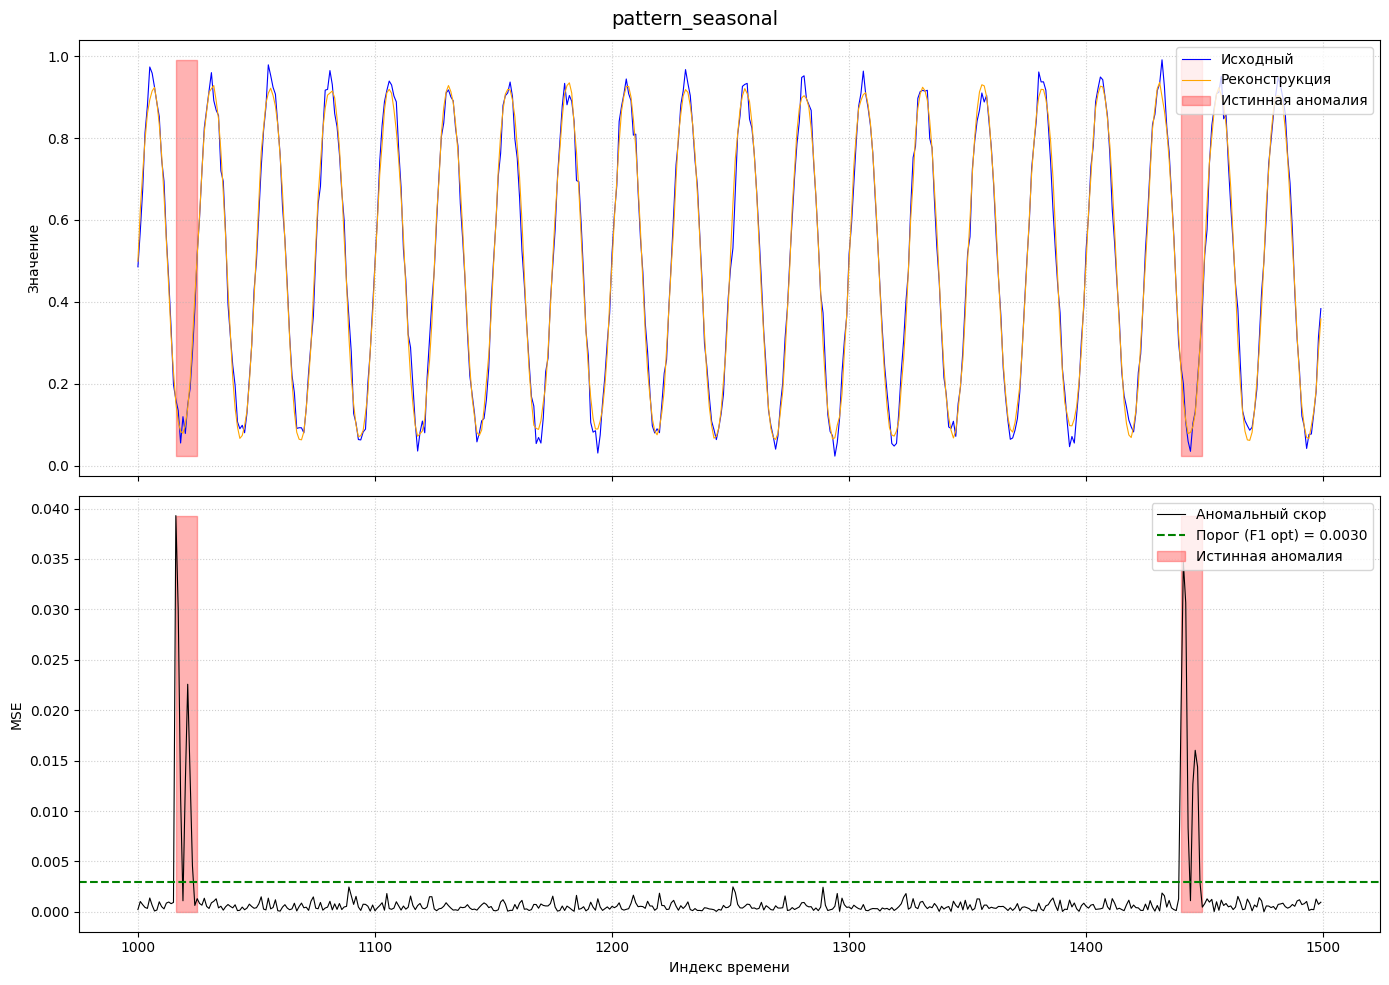

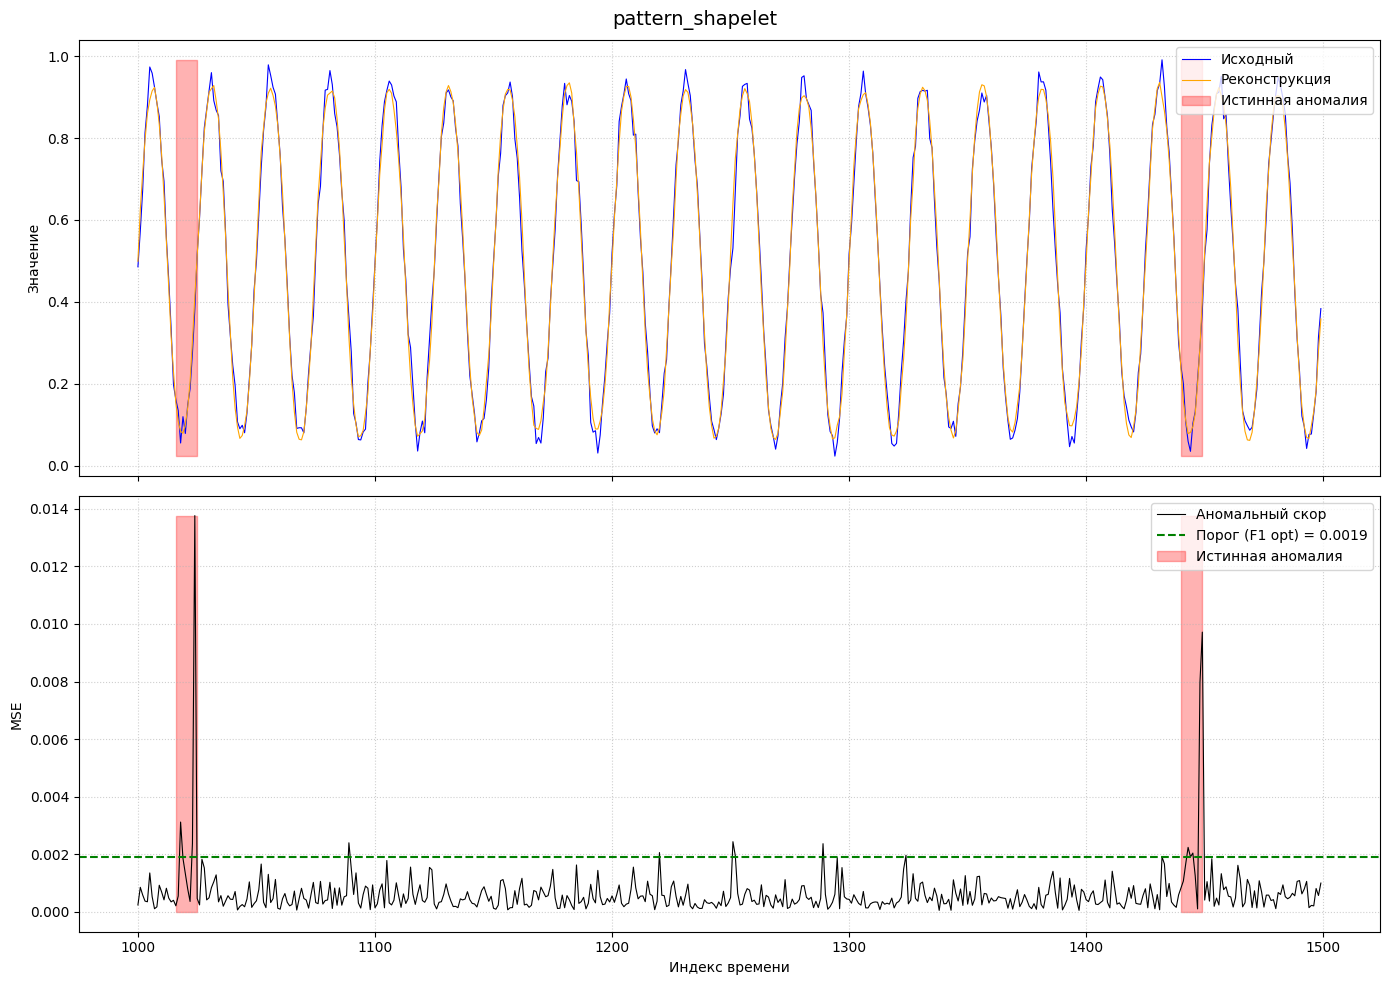

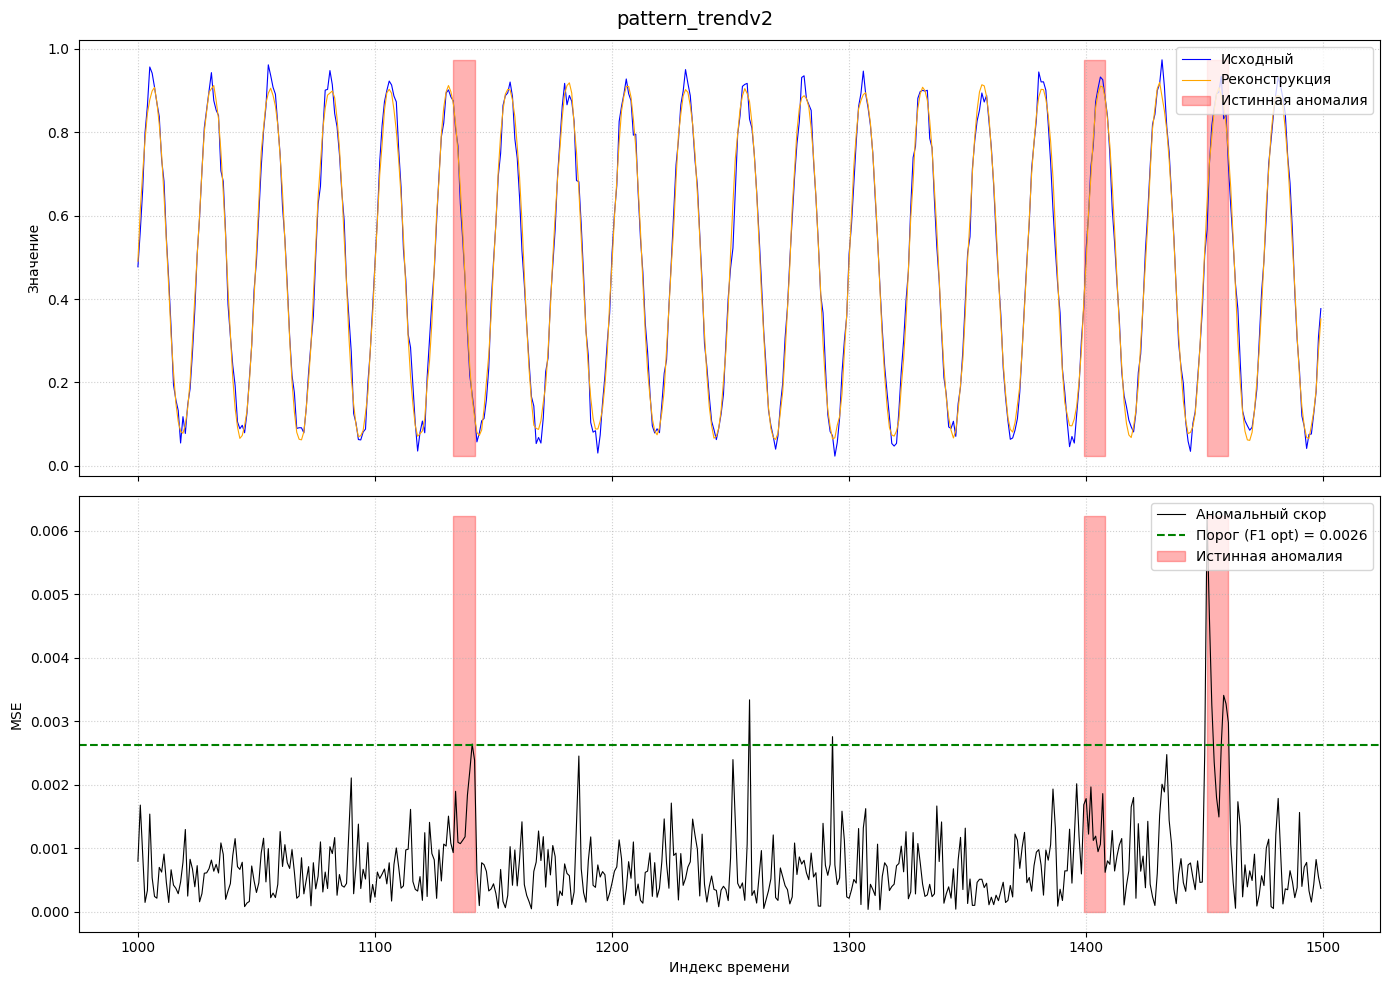

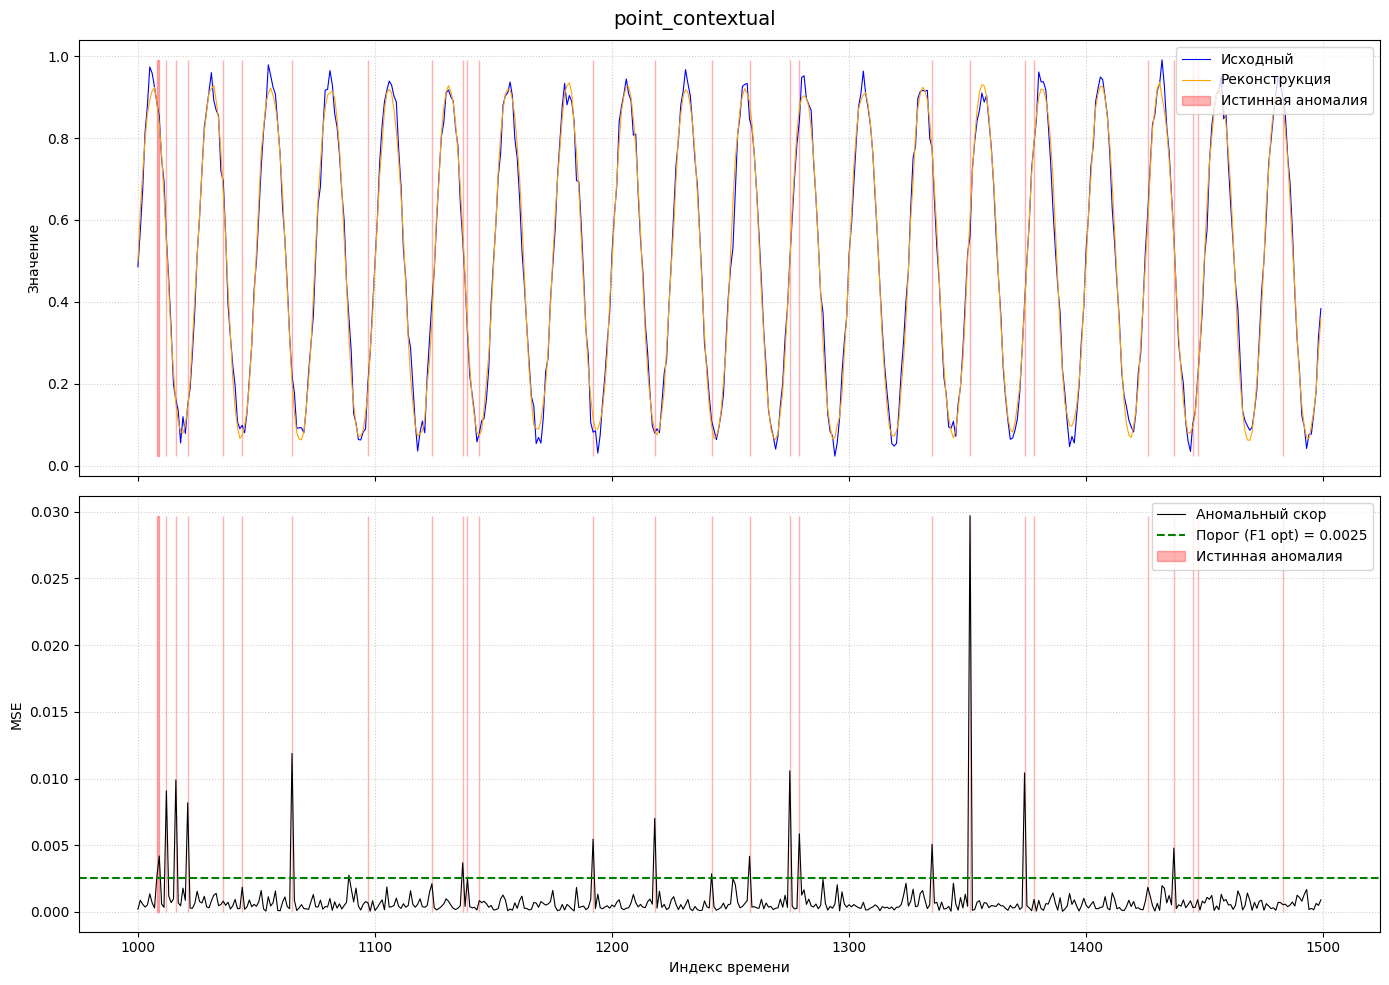

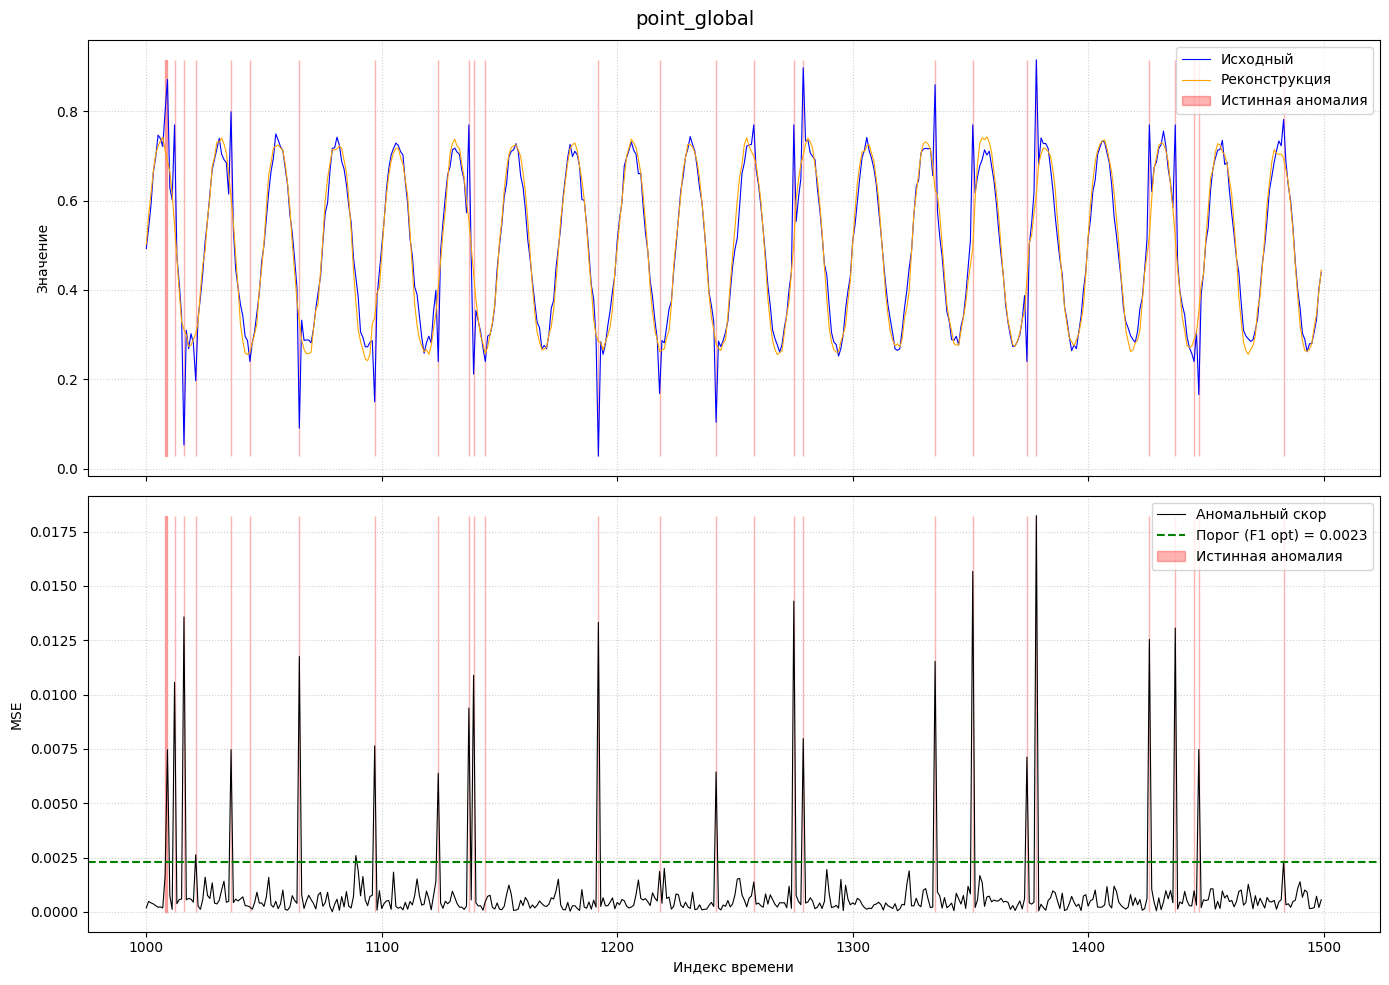

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

window_display = 512

for ds_name, data in all_plot_data.items():
    trues_full = data['trues_full']
    preds_full = data['preds_full']
    labels_full = data['labels_full']
    anomaly_scores = data['anomaly_scores']
    total_length = data['total_length']

    anomaly_idx = np.where(labels_full == 1)[0]
    if len(anomaly_idx) > 0:
        start = max(0, anomaly_idx[0] - window_display)
        end = min(total_length, anomaly_idx[-1] + window_display)
    else:
        start, end = 0, min(2048, total_length)

    start, end = 1000, 1500

    time_axis = np.arange(start, end)

    precisions, recalls, thresholds = precision_recall_curve(labels_full, anomaly_scores)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    optimal_threshold = thresholds[np.argmax(f1_scores)] if len(thresholds) > 0 else 0

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"{ds_name}", fontsize=14)

    ax = axes[0]
    ax.plot(time_axis, trues_full[start:end, 0], 'b-', linewidth=0.8, label='Исходный')
    ax.plot(time_axis, preds_full[start:end, 0], 'orange', linewidth=0.8, label='Реконструкция')
    ax.fill_between(time_axis,
                     min(trues_full[start:end, 0].min(), preds_full[start:end, 0].min()),
                     max(trues_full[start:end, 0].max(), preds_full[start:end, 0].max()),
                     where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_ylabel('Значение')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    ax = axes[1]
    ax.plot(time_axis, anomaly_scores[start:end], 'k-', linewidth=0.8, label='Аномальный скор')
    ax.axhline(y=optimal_threshold, color='green', linestyle='--', linewidth=1.5,
               label=f'Порог (F1 opt) = {optimal_threshold:.4f}')
    ax.fill_between(time_axis, 0, anomaly_scores[start:end].max(),
                     where=(labels_full[start:end] == 1), color='red', alpha=0.3, label='Истинная аномалия')
    ax.set_xlabel('Индекс времени')
    ax.set_ylabel('MSE')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    # fig.savefig(f"{ds_name}_reconstruction_plot_finetuned.png", dpi=150)
    plt.close(fig)